In [1]:
# 📌 Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings("ignore")

In [2]:
# 📌 Step 2: Load Dataset
df = pd.read_csv('diabetes2.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72,35.0,0.0,33.6,0.627,50.0,1
1,1.0,85.0,66,29.0,0.0,26.6,0.351,31.0,0
2,8.0,183.0,64,0.0,0.0,23.3,0.672,32.0,1
3,1.0,89.0,66,23.0,94.0,NaN,0.167,21.0,0
4,0.0,137.0,40,NaN,168.0,43.1,2.288,33.0,1


In [3]:
# Dataset dimensions - (rows, columns)
df.shape

(768, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               763 non-null    float64
 1   Glucose                   760 non-null    float64
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             766 non-null    float64
 4   Insulin                   766 non-null    float64
 5   BMI                       764 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       761 non-null    float64
 8   Outcome                   768 non-null    int64  
dtypes: float64(7), int64(2)
memory usage: 54.1 KB


In [5]:
# Statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,763.0,3.817824,3.358633,0.000,1.00000,3.0000,6.00000,17.00
Glucose,760.0,120.994737,31.954018,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,766.0,20.484334,15.937841,0.000,0.00000,23.0000,32.00000,99.00
Insulin,766.0,79.443864,115.177130,0.000,0.00000,27.0000,126.00000,846.00
BMI,764.0,31.995288,7.885450,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,761.0,33.210250,11.717978,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [6]:
# Count of null values
df.isnull().sum()

Pregnancies                 5
Glucose                     8
BloodPressure               0
SkinThickness               2
Insulin                     2
BMI                         4
DiabetesPedigreeFunction    0
Age                         7
Outcome                     0
dtype: int64

 Data Visualization

<Axes: xlabel='Outcome', ylabel='count'>

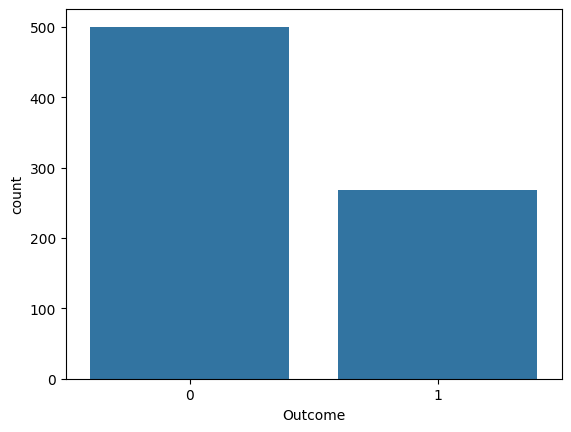

In [7]:
# Outcome countplot
sns.countplot(x = 'Outcome',data = df)

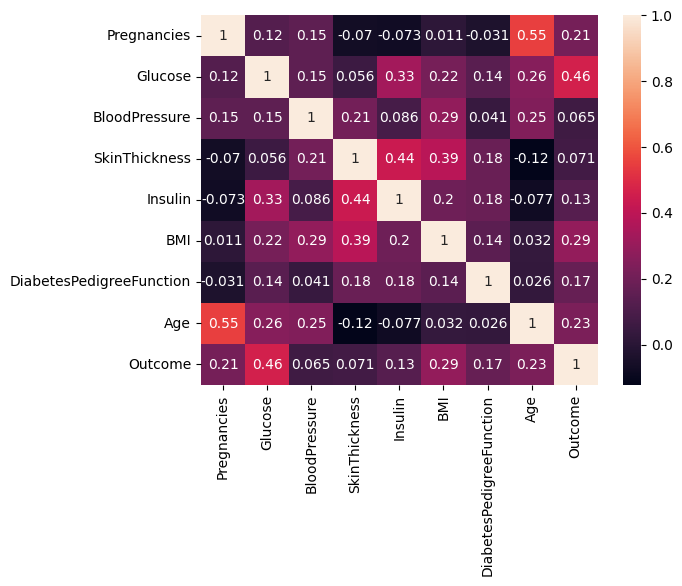

In [8]:
# Heatmap
sns.heatmap(df.corr(), annot = True)
plt.show()

Data Preprocessing

In [9]:
# Count of NaN
df.isnull().sum()

Pregnancies                 5
Glucose                     8
BloodPressure               0
SkinThickness               2
Insulin                     2
BMI                         4
DiabetesPedigreeFunction    0
Age                         7
Outcome                     0
dtype: int64

In [10]:
# 📌 Step 3: Replace 0s with NaN in specific columns and impute with median
zero_invalid_cols = ['Glucose', 'BMI','Age','Pregnancies','DiabetesPedigreeFunction','Insulin',"SkinThickness","BloodPressure"]
df[zero_invalid_cols] = df[zero_invalid_cols].replace(0, np.nan)
df[zero_invalid_cols] = df[zero_invalid_cols].fillna(df[zero_invalid_cols].median())


In [ ]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [12]:
# 📌 Step 6: Feature Scaling
X = df.drop('Outcome', axis=1)
y = df['Outcome']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
# 📌 Step 7: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [14]:
# 📌 Step 8: Model Building and Evaluation Functions
def evaluate_model(model, name):
    y_pred = model.predict(X_test)
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test)[:,1]
        auc = roc_auc_score(y_test, probs)
        fpr, tpr, _ = roc_curve(y_test, probs)
        # plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")


Train & Evaluate Model

In [15]:

# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
evaluate_model(lr, "Logistic Regression")

--- Logistic Regression ---
Accuracy: 0.7532467532467533
Confusion Matrix:
 [[83 16]
 [22 33]]
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.84      0.81        99
           1       0.67      0.60      0.63        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



In [30]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
evaluate_model(dt, "Decision Tree")

--- Decision Tree ---
Accuracy: 0.7402597402597403
Confusion Matrix:
 [[76 23]
 [17 38]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.77      0.79        99
           1       0.62      0.69      0.66        55

    accuracy                           0.74       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.74      0.74       154



In [17]:
# Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)
evaluate_model(nb, "Naive Bayes")

--- Naive Bayes ---
Accuracy: 0.7467532467532467
Confusion Matrix:
 [[79 20]
 [19 36]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.80      0.80        99
           1       0.64      0.65      0.65        55

    accuracy                           0.75       154
   macro avg       0.72      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



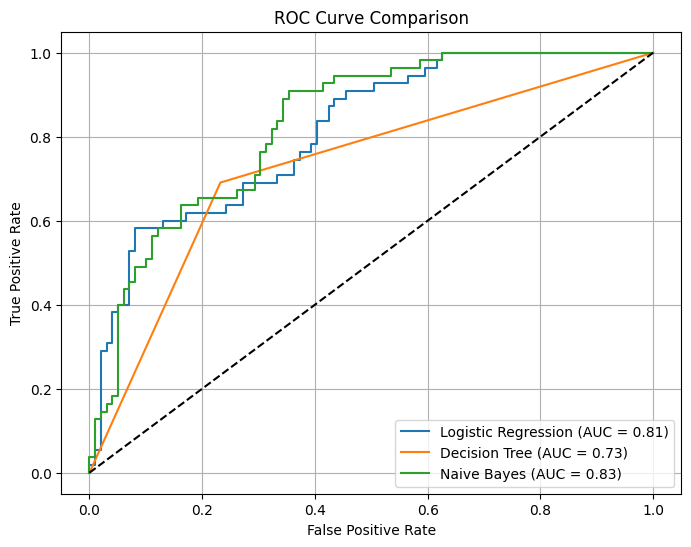

In [18]:
# 📌 Step: Plot ROC Curve for all 3 models together

plt.figure(figsize=(8, 6))

# Logistic Regression
lr_probs = lr.predict_proba(X_test)[:, 1]
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
lr_auc = roc_auc_score(y_test, lr_probs)
plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC = {lr_auc:.2f})")

# Decision Tree
dt_probs = dt.predict_proba(X_test)[:, 1]
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)
dt_auc = roc_auc_score(y_test, dt_probs)
plt.plot(dt_fpr, dt_tpr, label=f"Decision Tree (AUC = {dt_auc:.2f})")

# Naive Bayes
nb_probs = nb.predict_proba(X_test)[:, 1]
nb_fpr, nb_tpr, _ = roc_curve(y_test, nb_probs)
nb_auc = roc_auc_score(y_test, nb_probs)
plt.plot(nb_fpr, nb_tpr, label=f"Naive Bayes (AUC = {nb_auc:.2f})")

# Plot the random guess line
plt.plot([0, 1], [0, 1], 'k--')

# Labels and legend
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


HyperParameter Tuning (Using Tested Parameters)

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Apply the best hyperparameter to Logistic Regression (try a range of values for 'C')
lr_best = LogisticRegression(C=0.01, random_state=42)
lr_best.fit(X_train, y_train)

# Predictions and accuracy
y_pred_lr = lr_best.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy after Tuning: {accuracy_lr:.2f}")


Logistic Regression Accuracy after Tuning: 0.77


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Define a range of values for the hyperparameter 'C'
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

# Initialize Logistic Regression model
lr = LogisticRegression(random_state=42)

# Perform GridSearchCV with cross-validation
grid_search = GridSearchCV(lr, param_grid, cv=100, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Get the best hyperparameter value (C)
best_C = grid_search.best_params_['C']

# Train the model using the best hyperparameter (C)
lr_best = LogisticRegression(C=best_C, random_state=42)
lr_best.fit(X_train, y_train)

# Make predictions and calculate accuracy
y_pred_lr = lr_best.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print(f"Best Hyperparameter (C) for Logistic Regression: {best_C}")
print(f"Logistic Regression Accuracy after Tuning: {accuracy_lr:.2f}")


Best Hyperparameter (C) for Logistic Regression: 1
Logistic Regression Accuracy after Tuning: 0.75


In [39]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB

# Define parameter grid for Naive Bayes
param_grid_nb = {'var_smoothing': [1e-10, 1e-9, 1e-8, 1e-7, 1e-6]}

# Initialize Gaussian Naive Bayes
nb = GaussianNB()

# Perform GridSearchCV with cross-validation
grid_search_nb = GridSearchCV(nb, param_grid_nb, cv=5, scoring='accuracy')
grid_search_nb.fit(X_train, y_train)

# Get the best hyperparameter and the corresponding model
best_nb = grid_search_nb.best_estimator_

# Predictions and accuracy with the best hyperparameter
y_pred_nb = best_nb.predict(X_test)
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"Best var_smoothing for Naive Bayes: {grid_search_nb.best_params_}")
print(f"Naive Bayes Accuracy: {accuracy_nb:.2f}")


Best var_smoothing for Naive Bayes: {'var_smoothing': 1e-10}
Naive Bayes Accuracy: 0.75


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

# Define parameter grid for Decision Tree
param_grid_dt = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
}

# Initialize DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)

# Perform GridSearchCV with cross-validation
grid_search_dt = GridSearchCV(dt, param_grid_dt, cv=5, scoring='accuracy')
grid_search_dt.fit(X_train, y_train)

# Get the best hyperparameters
best_dt = grid_search_dt.best_estimator_

# Predictions and accuracy
y_pred_dt = best_dt.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Best Hyperparameters for Decision Tree: {grid_search_dt.best_params_}")
print(f"Decision Tree Accuracy after Hyperparameter Tuning: {accuracy_dt:.2f}")


Best Hyperparameters for Decision Tree: {'max_depth': 3, 'min_samples_split': 2}
Decision Tree Accuracy after Hyperparameter Tuning: 0.75


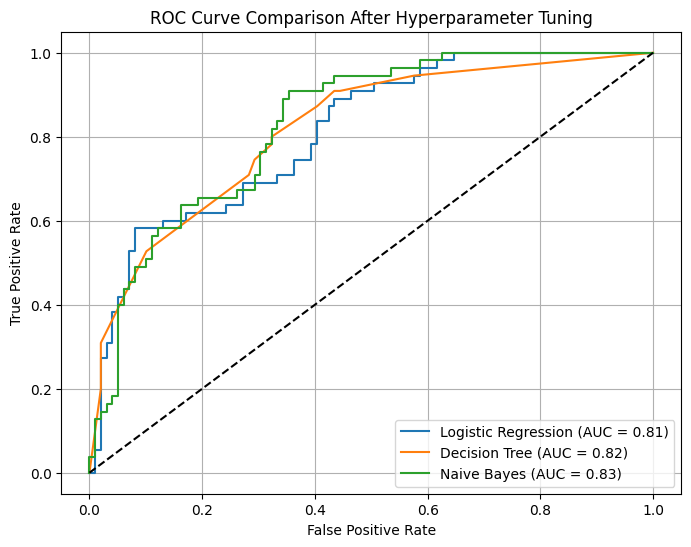

In [43]:
lr_probs = lr_best.predict_proba(X_test)[:, 1]
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
lr_auc = roc_auc_score(y_test, lr_probs)

nb_probs = nb_best.predict_proba(X_test)[:, 1]
nb_fpr, nb_tpr, _ = roc_curve(y_test, nb_probs)
nb_auc = roc_auc_score(y_test, nb_probs)

dt_probs = dt_best.predict_proba(X_test)[:, 1]
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)
dt_auc = roc_auc_score(y_test, dt_probs)

plt.figure(figsize=(8, 6))

# Plot ROC curve for Logistic Regression
plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC = {lr_auc:.2f})")

# Plot ROC curve for Decision Tree
plt.plot(dt_fpr, dt_tpr, label=f"Decision Tree (AUC = {dt_auc:.2f})")

# Plot ROC curve for Naive Bayes
plt.plot(nb_fpr, nb_tpr, label=f"Naive Bayes (AUC = {nb_auc:.2f})")

# Plot the random guess line
plt.plot([0, 1], [0, 1], 'k--')

# Labels and legend
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison After Hyperparameter Tuning")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()